# Notebook 03 — Data-Only Neural Network Survival Model

Implements a neural network that takes `(x, t)` as input and directly predicts survival probability `S(x, t) ∈ (0, 1)`.

**Purpose:** Establish a purely data-driven survival baseline and demonstrate its key failure mode — non-monotonic survival curves — which motivates the physics-informed approach in Notebook 04.

In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## Load Clean Survival Dataset

In [7]:
df = pd.read_csv('../data/lendingclub_survival_clean.csv')
df.shape

(2247571, 13)

## Feature Engineering

Four loan-level features are used across all notebooks to keep comparisons clean.
Time `t` is appended to each input so the network can learn time-varying risk.

In [8]:
features = ['annual_inc','dti','loan_amnt','int_rate']

X = df[features].values
t = df['time'].values.reshape(-1, 1)
event = df['event'].values.reshape(-1, 1)

# Standardize features
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X = (X - X_mean) / X_std

# Convert to tensors
X = torch.tensor(X, dtype=torch.float32)
t = torch.tensor(t, dtype=torch.float32)
event = torch.tensor(event, dtype=torch.float32)

## Train / Test Split

In [9]:
n = X.shape[0]
idx = torch.randperm(n)
train_size = int(0.7 * n)

train_idx = idx[:train_size]
test_idx = idx[train_size:]

X_tr, X_te = X[train_idx], X[test_idx]
t_tr, t_te = t[train_idx], t[test_idx]
e_tr, e_te = event[train_idx], event[test_idx]

## Neural Network Definition

The network maps `(x, t) → S ∈ (0, 1)`. A Sigmoid output ensures predictions are bounded, but **no monotonicity in `t` is enforced** — the network can freely predict `S(t+1) > S(t)`.

This is an intentional design choice to demonstrate the failure mode before introducing PINN constraints.

In [10]:
class SurvivalNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = SurvivalNN(X.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Loss Function — Simplified Binary Likelihood

We use a simplified loss that treats survival as a binary outcome at time `t`:

$$\mathcal{L} = -\delta \log(1 - S(t)) - (1-\delta)\log(S(t))$$

where $\delta = 1$ indicates an observed default and $S(t)$ is the predicted survival probability.

**Important caveat on censoring:** This loss pushes censored observations ($\delta = 0$) toward $S(t) \approx 1$, treating them as permanently surviving rather than as right-censored at time `t`. The theoretically correct survival log-likelihood is:

$$\mathcal{L}_{\text{survival}} = -\delta\,[\log\lambda(t) + \log S(t)] - (1-\delta)\log S(t)$$

The naive form is used deliberately here to produce unstable survival curves, motivating the PINN in Notebook 04.

In [11]:
def loss_fn(S, t, e):
    eps = 1e-6
    return torch.mean(-e * torch.log(1 - S + eps) - (1 - e) * torch.log(S + eps))

## Training Loop

In [12]:
epochs = 20

for epoch in range(epochs):
    optimizer.zero_grad()
    S_pred = model(X_tr, t_tr)
    loss = loss_fn(S_pred, t_tr, e_tr)
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        print(f'Epoch {epoch}, Loss {loss.item():.4f}')

Epoch 0, Loss 0.5800
Epoch 5, Loss 0.4101
Epoch 10, Loss 0.4129
Epoch 15, Loss 0.4133


## Survival Curves — Demonstrating Non-Monotonicity

Plot `S(t)` for 5 held-out borrowers across a 60-month horizon.
Because no monotonicity constraint is enforced, `S(t)` can increase over time — a theoretical impossibility in survival analysis, where the survival function must be non-increasing.

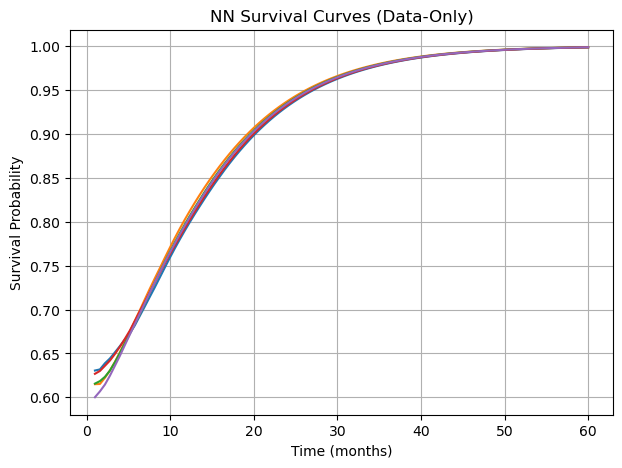

In [13]:
model.eval()

sample = X_te[:50]
time_grid = torch.linspace(1, 60, 100).reshape(-1,1)

plt.figure(figsize=(7,5))
for i in range(5):
    x_i = sample[i].repeat(100,1)
    S_i = model(x_i, time_grid).detach().numpy()
    plt.plot(time_grid.numpy(), S_i)

plt.xlabel('Time (months)')
plt.ylabel('Survival Probability')
plt.title('NN Survival Curves (Data-Only)')
plt.grid(True)
plt.show()

## Key Observations

- **Non-monotonic survival curves** — `S(t)` can increase, violating survival theory
- **Censoring bias** — the naive loss mishandles right-censored observations
- **Unstable extrapolation** — no structural guarantee about predictions beyond the training range

### What is needed

Embedding the survival ODE as a constraint:

$$\frac{dS}{dt} = -\lambda(t) \cdot S(t), \quad \lambda(t) \geq 0$$

guarantees $S(t)$ is monotonically decreasing and probabilistically valid. This is implemented in **Notebook 04** using a Physics-Informed Neural Network.